# last_gen WZA Manhattans — SNP / smallindel / SV

kMate GrENE-Net **phase-1 replication**, matched **last_gen** pool set (355 pools = 89 gen1 + 73 gen2 + 193 gen3, last-available-per-plot).

Per-record GEA → **WZA** (deg-7 SNP-number correction, Booker), **separate per variant class**. y = -log10(WZA block p). CAM5 (block `2_1265`, Chr2 ~11.53 Mb) circled in green.

Two models, both shown below:
- **Kendall-τ → WZA** (raw association; no structure correction)
- **LFMM K=16 → WZA** (structure-corrected; phase-1's other model)

Watch the Chr4 ~12 Mb peak (block `4_2519`): real, survives both. Block `4_2781` (Chr4 ~15.5 Mb) is strong in Kendall but collapses under LFMM (structure).

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

WDIR = "/global/scratch/users/tbellg/kmate/analysis/grenenet_gea/r2_gea_nonsnp/phase1_replication/results/wza"
TAG  = "deg7nocap"
CLASSES = ["snp", "smallindel", "sv"]
CAM5_BLOCK = "2_1265"
CHROMS = [f"Chr{i}" for i in range(1, 6)]

def load(model, cls):
    w = pd.read_csv(f"{WDIR}/wza_{model}_{cls}_gen9_bio1_{TAG}.csv").rename(columns={"index": "block"})
    w["block"] = w["block"].astype(str)
    w = w[w["Z_pVal"].notna()].copy()
    w["chrom"] = w["chrom"].astype(str)
    w = w[w["chrom"].isin(CHROMS)]
    w["mlogp"] = -np.log10(w["Z_pVal"].clip(lower=1e-300))
    return w

def manhattan(model):
    allpos = pd.concat([load(model, c)[["chrom", "pos"]] for c in CLASSES])
    chrom_max = allpos.groupby("chrom")["pos"].max().reindex(CHROMS).fillna(0)
    offset  = chrom_max.cumsum().shift(1).fillna(0)
    centers = offset + chrom_max / 2
    fig, axes = plt.subplots(len(CLASSES), 1, figsize=(14, 9), sharex=True)
    colors = ["#3b6fb6", "#9bbce0"]
    for ax, cls in zip(axes, CLASSES):
        w = load(model, cls); w["x"] = w["pos"] + w["chrom"].map(offset); n = len(w)
        bonf = -np.log10(0.05 / n)
        p = np.sort(w["Z_pVal"].to_numpy()); m = len(p)
        bh = np.where(p <= 0.05 * (np.arange(1, m + 1) / m))[0]
        bh_p = p[bh.max()] if len(bh) else None
        for i, ch in enumerate(CHROMS):
            s = w[w["chrom"] == ch]
            ax.scatter(s["x"], s["mlogp"], s=6, c=colors[i % 2], rasterized=True)
        ax.axhline(bonf, color="red", lw=0.8, ls="--", label=f"Bonferroni 0.05/{n}")
        if bh_p: ax.axhline(-np.log10(bh_p), color="orange", lw=0.8, ls=":", label="BH q<0.05")
        c5 = w[w["block"] == CAM5_BLOCK]
        if len(c5):
            ax.scatter(c5["x"], c5["mlogp"], s=70, facecolors="none", edgecolors="green", linewidths=1.8, zorder=5)
            ax.annotate("CAM5", (c5["x"].iloc[0], c5["mlogp"].iloc[0]), color="green", fontsize=9,
                        xytext=(6, 4), textcoords="offset points")
        ax.set_ylabel(f"{cls}\n-log10(WZA p)")
        ax.legend(loc="upper right", fontsize=7, framealpha=0.9)
        ax.set_title(f"{cls}: {n:,} blocks | CAM5 " + (f"-log10p={c5['mlogp'].iloc[0]:.2f}" if len(c5) else "absent"),
                     fontsize=9, loc="left")
    axes[-1].set_xticks(centers); axes[-1].set_xticklabels(CHROMS); axes[-1].set_xlabel("genome position (LD-block)")
    fig.suptitle(f"last_gen {model}\u2192WZA Manhattan (deg-7) \u2014 kMate phase-1 replication", y=0.995)
    plt.tight_layout(); plt.show()

## Kendall-τ → WZA (raw association)

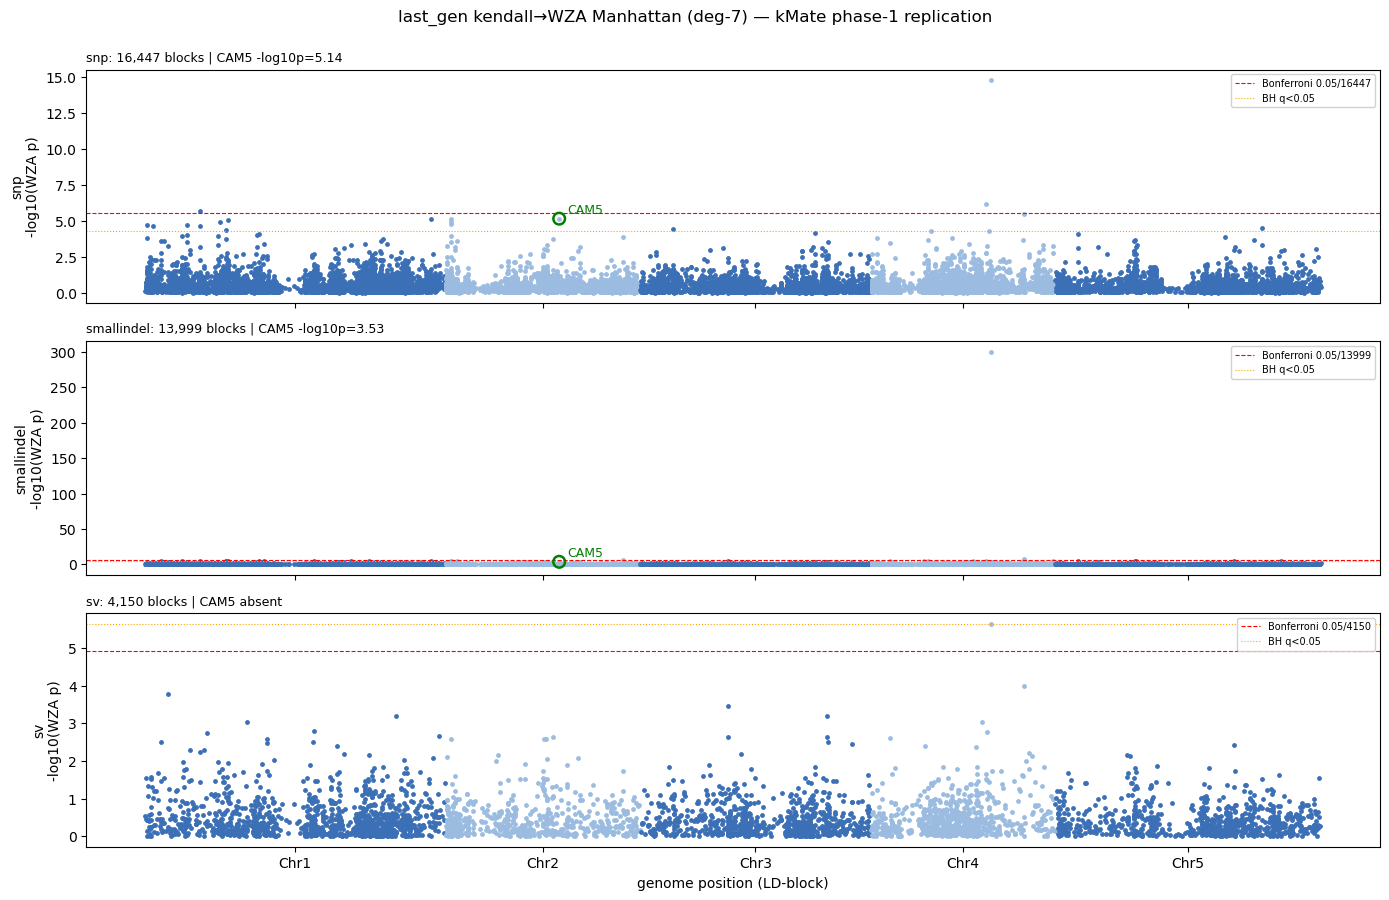

In [2]:
manhattan("kendall")

## LFMM (K=16) → WZA (structure-corrected)

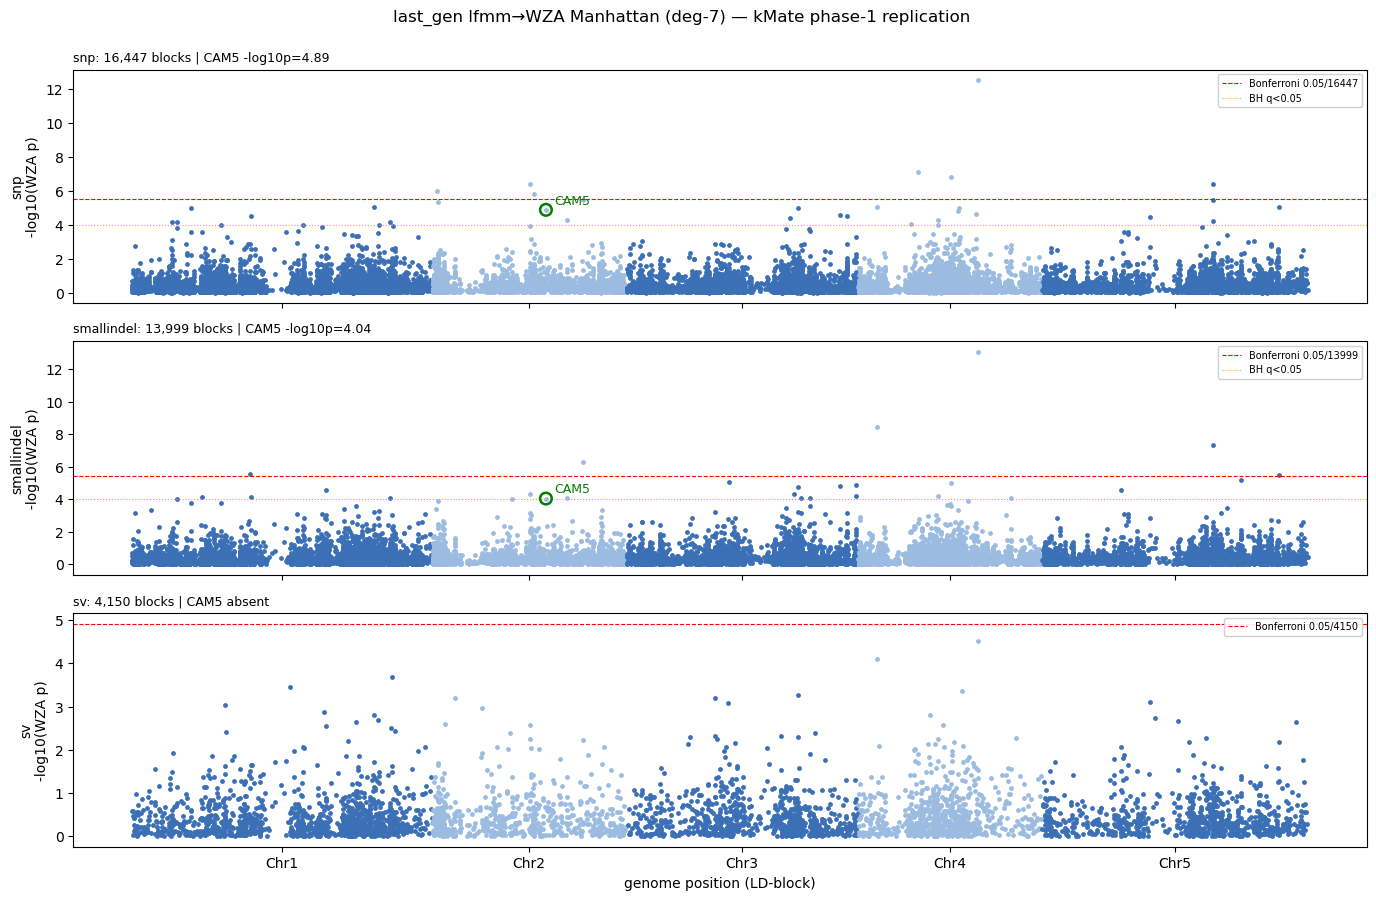

In [3]:
manhattan("lfmm")

## Summary table (both models)

In [4]:
def bh_q(p):
    p = np.asarray(p, float); n = len(p); o = np.argsort(p); q = np.empty(n)
    q[o] = (p[o] * n) / (np.arange(n) + 1); q[o] = np.minimum.accumulate(q[o][::-1])[::-1]; return np.clip(q, 0, 1)
rows = []
for model in ["kendall", "lfmm"]:
    for cls in CLASSES:
        w = load(model, cls).sort_values("Z_pVal").reset_index(drop=True); n = len(w)
        p = w["Z_pVal"].to_numpy(); q = bh_q(p); r = w.index[w["block"] == CAM5_BLOCK]
        rows.append(dict(model=model, cls=cls, blocks=n, Bonf=int((p < 0.05/n).sum()), BH_q05=int((q < 0.05).sum()),
                         CAM5_rank=(int(r[0])+1 if len(r) else None),
                         CAM5_p=(f"{w.loc[r[0],'Z_pVal']:.2e}" if len(r) else "absent"),
                         CAM5_q=(round(float(q[int(r[0])]),3) if len(r) else None)))
pd.DataFrame(rows)

,model,cls,blocks,Bonf,BH_q05,CAM5_rank,CAM5_p,CAM5_q
0,kendall,snp,16447,3,20,5.0,7.25e-06,0.019
1,kendall,smallindel,13999,3,31,41.0,2.96e-04,0.101
2,kendall,sv,4150,1,1,NaN,absent,NaN
3,lfmm,snp,16447,7,35,17.0,1.30e-05,0.013
4,lfmm,smallindel,13999,6,26,26.0,9.06e-05,0.049
5,lfmm,sv,4150,0,0,NaN,absent,NaN
